# Extracting features and embeddings of TUNI VTC Dataset



## 1. Setup

In [32]:
import types, importlib, sys
imp = types.ModuleType("imp")
imp.reload = importlib.reload
sys.modules["imp"] = imp
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [34]:
import sys
print(sys.path[0])

/home/suvihaara/Documents/PhD/CODE/audio_embeddings_and_feature_extraction_from_audio_dataset


In [31]:
from pathlib import Path
import shutil

wav_root = Path("/home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/wav")

emotion_mapping = {
    "suru": "sadness",
    "ilo": "joy",
    "viha": "anger",
    "lempeys": "gentleness",
    "neutraali": "neutral",
}

for singer_dir in wav_root.iterdir():
    if not singer_dir.is_dir():
        continue

    for genre_dir in singer_dir.iterdir():
        if not genre_dir.is_dir():
            continue

        for file in genre_dir.iterdir():
            if not file.is_file():
                continue

            filename_lower = file.name.lower()

            matched_emotion = None
            for keyword, emotion in emotion_mapping.items():
                if keyword in filename_lower:
                    matched_emotion = emotion
                    break

            if matched_emotion:
                emotion_dir = genre_dir / matched_emotion
                emotion_dir.mkdir(exist_ok=True)

                destination = emotion_dir / file.name

                shutil.move(str(file), str(destination))

                print(f"Moved: {file.name} → {matched_emotion}/")

            else:
                print(f"NO MATCH: {file}")

Moved: Liisi_Petterson_2_neutraali_1a1.wav → neutral/
Moved: Liisi_Petterson_2_suru_3a1.wav → sadness/
Moved: Liisi_Petterson_2_viha_3a.wav → anger/
Moved: Liisi_Petterson_2_viha_1e.wav → anger/
Moved: Liisi_Petterson_2_lempeys_2a1.wav → gentleness/
Moved: Liisi_Petterson_2_ilo_1a1.wav → joy/
Moved: Liisi_Petterson_2_ilo_2e.wav → joy/
Moved: Liisi_Petterson_2_ilo_3a1.wav → joy/
Moved: Liisi_Petterson_2_lempeys_1a.wav → gentleness/
Moved: Liisi_Petterson_2_suru_2e.wav → sadness/
Moved: Liisi_Petterson_2_lempeys_2e.wav → gentleness/
Moved: Liisi_Petterson_2_neutraali_3a1.wav → neutral/
Moved: Liisi_Petterson_2_neutraali_3e.wav → neutral/
Moved: Liisi_Petterson_2_neutraali_2e.wav → neutral/
Moved: Liisi_Petterson_2_neutraali_1e.wav → neutral/
Moved: Liisi_Petterson_2_ilo_1a.wav → joy/
Moved: Liisi_Petterson_2_lempeys_1e.wav → gentleness/
Moved: Liisi_Petterson_2_ilo_2a1.wav → joy/
Moved: Liisi_Petterson_2_suru_2a1.wav → sadness/
Moved: Liisi_Petterson_2_viha_1a1.wav → anger/
Moved: Liisi_

In [35]:
from TUNI_data_config import tuni_emotion_dataset_config
from TUNI_extraction_config import TUNI_extraction
from scripts.validate_config import validate_configs

# Create dataset instance by calling the function
tuni_emotion_dataset = tuni_emotion_dataset_config()

print(f"Dataset: {tuni_emotion_dataset.name}")
print(f"Root directory: {tuni_emotion_dataset.root_dir}")
print(f"Levels: {tuni_emotion_dataset.level_names}")

# View extraction configuration
print(f"\nExtractors: {TUNI_extraction.extractors}")
print(f"Output directory: {TUNI_extraction.output_dir}")
print(f"Window lengths: {TUNI_extraction.window_lengths}")

# Validate configurations
try:
    validate_configs(tuni_emotion_dataset, TUNI_extraction)
    print("\n✓ Configurations are valid!")
except ValueError as e:
    print(f"\n✗ Configuration error: {e}")

Dataset: tuni_emotion_dataset
Root directory: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/wav
Levels: ['singer', 'genre', 'emotion']

Extractors: ['opensmile', 'clap', 'whisper']
Output directory: /home/suvihaara//Documents/PhD/DATA/TUNI_emotion_dataset/embeddings
Window lengths: [3.0, 0.5]

✓ Configurations are valid!


## 2. Run Extractions

In [36]:
import logging
from scripts.run_extraction import run_extraction
from pathlib import Path

# Run extraction (this may take a while depending on dataset size)
log_file = "/home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/TUNI_extraction_log.txt"

# Pass file paths to run_extraction (not the config objects)
run_extraction(
    dataset_config_path="TUNI_data_config.py",
    extraction_config_path="TUNI_extraction_config.py",
    log_file=log_file,
    console_output=False, # aim to reduce memory use of VSCode so the session doesnt crash
    overwrite=True
)

print(f"✓ Extraction complete! Logs saved to {log_file}")

[INFO] OpenSMILE compare-2016: 6373 features
[INFO] 900 total files | 0 already processed | 900 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_opensmile-compare-2016_3.0s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_opensmile-compare-2016_3.0s.parquet


[opensmile-compare-2016] tuni_emotion_dataset: 100%|██████████| 900/900 [00:28<00:00, 32.04file/s, frames=102, file=Veera_Tapanainen_1_suru_3e.wav, extracted=1]    


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_opensmile-compare-2016_3.0s.parquet
[INFO] 913 total frame embeddings from 900 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_opensmile-compare-2016_3.0s.json
[INFO] Cleaned up HDF5 and checkpoint files.
[INFO] Loading CLAP 2023 (cuda=True)
[INFO] 900 total files | 0 already processed | 900 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_3.0s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_3.0s.parquet


[clap-2023] tuni_emotion_dataset: 100%|██████████| 900/900 [01:58<00:00,  7.57file/s, frames=102, file=Veera_Tapanainen_1_suru_3e.wav, extracted=1]    


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_3.0s.parquet
[INFO] 913 total frame embeddings from 900 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_3.0s.json
[INFO] Cleaned up HDF5 and checkpoint files.
[INFO] Loading Whisper encoder (openai/whisper-base) on cuda
[INFO] 900 total files | 0 already processed | 900 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_whisper_whisper-base_3.0s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_whisper_whisper-base_3.0s.parquet


...

[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_opensmile-compare-2016_0.5s.parquet
[INFO] 5658 total frame embeddings from 900 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_opensmile-compare-2016_0.5s.json
[INFO] Cleaned up HDF5 and checkpoint files.
[INFO] Loading CLAP 2023 (cuda=True)
[INFO] 900 total files | 0 already processed | 900 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_0.5s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_0.5s.parquet


[clap-2023] tuni_emotion_dataset: 100%|██████████| 900/900 [05:02<00:00,  2.97file/s, frames=574, file=Veera_Tapanainen_1_suru_3e.wav, extracted=7]      


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_0.5s.parquet
[INFO] 5658 total frame embeddings from 900 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_clap-2023_0.5s.json
[INFO] Cleaned up HDF5 and checkpoint files.
[INFO] Loading Whisper encoder (openai/whisper-base) on cuda
[INFO] 900 total files | 0 already processed | 900 remaining
[INFO] HDF5 accumulation file: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_whisper_whisper-base_0.5s.h5
[INFO] Final output: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_whisper_whisper-base_0.5s.parquet


[whisper_whisper-base] tuni_emotion_dataset: 100%|██████████| 900/900 [00:56<00:00, 16.03file/s, frames=574, file=Veera_Tapanainen_1_suru_3e.wav, extracted=7]      


[INFO] Converting HDF5 to Parquet...
[INFO] Parquet saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_whisper_whisper-base_0.5s.parquet
[INFO] 5658 total frame embeddings from 900 files.
[INFO] Metadata saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/tuni_emotion_dataset_whisper_whisper-base_0.5s.json
[INFO] Cleaned up HDF5 and checkpoint files.
✓ Extraction complete! Logs saved to /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/TUNI_extraction_log.txt


In [37]:

# Check the logs to see what happened during extraction
import json
from pathlib import Path

log_file = Path("/home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/TUNI_extraction_log.txt")

print(f"Log file: {log_file}")
print(f"File exists: {log_file.exists()}")
print(f"File size: {log_file.stat().st_size if log_file.exists() else 'N/A'} bytes")

if log_file.exists():
    print("\n--- Last 20 log entries ---")
    with open(log_file) as f:
        lines = f.readlines()
        for line in lines[-20:]:
            entry = json.loads(line.strip())
            stage = entry.get("stage", "?")
            level = entry.get("level", "?")
            message = entry.get("message", "")[:80]  # First 80 chars
            print(f"[{level:5s}] {stage:25s} | {message}")


Log file: /home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/TUNI_extraction_log.txt
File exists: True
File size: 7132 bytes

--- Last 20 log entries ---
[INFO ] initialization            | Extraction pipeline starting
[INFO ] extraction_start          | Starting extraction: opensmile @ 3.0s for tuni_emotion_dataset
[INFO ] extraction_complete       | Extraction complete: opensmile @ 3.0s | 900 files, 913 frames | 0 errors, 0 warn
[DEBUG] resource_checkpoint       | Resource checkpoint | CPU: 0.7% | RAM: 22.1GB used, 40.5GB available | GPU: 0.0G
[INFO ] extraction_start          | Starting extraction: clap @ 3.0s for tuni_emotion_dataset
[INFO ] extraction_complete       | Extraction complete: clap @ 3.0s | 900 files, 913 frames | 0 errors, 0 warnings 
[DEBUG] resource_checkpoint       | Resource checkpoint | CPU: 0.7% | RAM: 22.3GB used, 40.3GB available | GPU: 0.6G
[INFO ] extraction_start          | Starting extraction: whisper @ 3.0s for tuni_emotion_dataset
[INFO ]

In [38]:

# First, check what output files already exist
from pathlib import Path
output_dir = Path("/home/suvihaara/Documents/PhD/DATA/TUNI_emotion_dataset/embeddings/")

print("Existing parquet files:")
for f in sorted(output_dir.glob("*.parquet")):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  - {f.name:60s} ({size_mb:.1f} MB)")

print("\nExisting checkpoint files:")
checkpoints = list(output_dir.glob("*.checkpoint.jsonl"))
if checkpoints:
    for cp in sorted(checkpoints):
        print(f"  - {cp.name}")
else:
    print("  (none - these get cleaned up after successful extraction)")

print("\nExisting HDF5 files:")
h5_files = list(output_dir.glob("*.h5"))
if h5_files:
    for h5 in sorted(h5_files):
        print(f"  - {h5.name}")
else:
    print("  (none - these get cleaned up after successful extraction)")


Existing parquet files:
  - tuni_emotion_dataset_clap-2023_0.5s.parquet                  (22.2 MB)
  - tuni_emotion_dataset_clap-2023_3.0s.parquet                  (3.6 MB)
  - tuni_emotion_dataset_opensmile-compare-2016_0.5s.parquet     (127.6 MB)
  - tuni_emotion_dataset_opensmile-compare-2016_3.0s.parquet     (21.8 MB)
  - tuni_emotion_dataset_whisper_whisper-base_0.5s.parquet       (11.1 MB)
  - tuni_emotion_dataset_whisper_whisper-base_3.0s.parquet       (1.8 MB)

Existing checkpoint files:
  (none - these get cleaned up after successful extraction)

Existing HDF5 files:
  (none - these get cleaned up after successful extraction)


## 3. Explore results

In [39]:
from scripts.utils import load_parquet  
# Load extraction results

output_dir = Path(TUNI_extraction.output_dir)

# List all output files
output_files = list(output_dir.glob("*.parquet"))
print("Generated output files:")
for f in output_files:
    print(f"  - {f.name}")

Generated output files:
  - tuni_emotion_dataset_whisper_whisper-base_0.5s.parquet
  - tuni_emotion_dataset_clap-2023_3.0s.parquet
  - tuni_emotion_dataset_whisper_whisper-base_3.0s.parquet
  - tuni_emotion_dataset_opensmile-compare-2016_3.0s.parquet
  - tuni_emotion_dataset_opensmile-compare-2016_0.5s.parquet
  - tuni_emotion_dataset_clap-2023_0.5s.parquet


In [40]:
import os 
df_opensmile = load_parquet(
    os.path.join(output_dir, "tuni_emotion_dataset_opensmile-compare-2016_0.5s.parquet")
)

print(f"Data shape: {df_opensmile.shape}")
print(f"Columns: {list(df_opensmile.columns)}")
print(f"\nFirst few rows:")
df_opensmile.head()

Data shape: (5658, 10)
Columns: ['emotion', 'extractor', 'filename', 'filepath', 'frame_index', 'genre', 'singer', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,emotion,extractor,filename,filepath,frame_index,genre,singer,embedding,embedding_dtype,embedding_shape
0,anger,opensmile-compare-2016,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,0,classical,Anniina_Honkala,"[0.8836381, 0.7906977, 0.0, 0.71507955, 0.7944...",<f4,[6373]
1,anger,opensmile-compare-2016,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,1,classical,Anniina_Honkala,"[0.28991026, 0.046511628, 0.9767442, 0.6450271...",<f4,[6373]
2,anger,opensmile-compare-2016,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,2,classical,Anniina_Honkala,"[0.18248412, 0.0, 0.6744186, 0.4568332, 0.4925...",<f4,[6373]
3,anger,opensmile-compare-2016,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,3,classical,Anniina_Honkala,"[0.3674243, 0.069767445, 0.95348835, 0.3183869...",<f4,[6373]
4,anger,opensmile-compare-2016,Anniina_Honkala_2_viha_1a1,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,0,classical,Anniina_Honkala,"[1.4752457, 0.25581396, 0.0, 1.1340652, 1.2284...",<f4,[6373]


In [41]:
print("Total rows:", len(df_opensmile))
print("Rows with emotion:", df_opensmile["emotion"].notna().sum())
print("Rows missing emotion:", df_opensmile["emotion"].isna().sum())

print("\nEmotion counts:")
print(df_opensmile["emotion"].value_counts(dropna=False))

Total rows: 5658
Rows with emotion: 5658
Rows missing emotion: 0

Emotion counts:
emotion
joy           1157
neutral       1146
gentleness    1143
anger         1109
sadness       1103
Name: count, dtype: int64


In [42]:
print(df_opensmile["emotion"].unique())

['anger' 'gentleness' 'joy' 'neutral' 'sadness']


In [43]:
for emotion, count in df_opensmile["emotion"].value_counts(dropna=False).items():
    print(repr(emotion), count)

'joy' 1157
'neutral' 1146
'gentleness' 1143
'anger' 1109
'sadness' 1103


In [44]:
df_clap = load_parquet(
    os.path.join(output_dir, "tuni_emotion_dataset_clap-2023_0.5s.parquet")
)

print(f"Data shape: {df_clap.shape}")
print(f"Columns: {list(df_clap.columns)}")
print(f"\nFirst few rows:")
df_clap.head()

Data shape: (5658, 10)
Columns: ['emotion', 'extractor', 'filename', 'filepath', 'frame_index', 'genre', 'singer', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,emotion,extractor,filename,filepath,frame_index,genre,singer,embedding,embedding_dtype,embedding_shape
0,anger,clap-2023,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,0,classical,Anniina_Honkala,"[-0.740003, -1.2840401, 0.036385536, 0.9890896...",<f4,[1024]
1,anger,clap-2023,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,1,classical,Anniina_Honkala,"[1.1179435, -1.2883692, 0.4162828, 0.49950433,...",<f4,[1024]
2,anger,clap-2023,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,2,classical,Anniina_Honkala,"[1.1915123, -1.6083341, -0.15577757, 0.5679184...",<f4,[1024]
3,anger,clap-2023,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,3,classical,Anniina_Honkala,"[1.2291585, -0.66317695, 0.03149376, 0.5293525...",<f4,[1024]
4,anger,clap-2023,Anniina_Honkala_2_viha_1a1,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,0,classical,Anniina_Honkala,"[0.36304092, -0.7894701, -0.37961236, 1.424788...",<f4,[1024]


In [45]:
df_whisper = load_parquet(
    os.path.join(output_dir, "tuni_emotion_dataset_whisper_whisper-base_0.5s.parquet")
)

print(f"Data shape: {df_whisper.shape}")
print(f"Columns: {list(df_whisper.columns)}")
print(f"\nFirst few rows:")
df_whisper.head()

Data shape: (5658, 10)
Columns: ['emotion', 'extractor', 'filename', 'filepath', 'frame_index', 'genre', 'singer', 'embedding', 'embedding_dtype', 'embedding_shape']

First few rows:


,emotion,extractor,filename,filepath,frame_index,genre,singer,embedding,embedding_dtype,embedding_shape
0,anger,whisper_whisper-base,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,0,classical,Anniina_Honkala,"[-0.07459527, -0.8243658, 0.27399462, -1.11897...",<f4,[512]
1,anger,whisper_whisper-base,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,1,classical,Anniina_Honkala,"[-0.085125856, -0.8279959, 0.30040225, -1.0937...",<f4,[512]
2,anger,whisper_whisper-base,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,2,classical,Anniina_Honkala,"[-0.114528604, -0.938042, 0.28797024, -1.11076...",<f4,[512]
3,anger,whisper_whisper-base,Anniina_Honkala_2_viha_1a,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,3,classical,Anniina_Honkala,"[-0.078025855, -0.8342661, 0.27512503, -1.0915...",<f4,[512]
4,anger,whisper_whisper-base,Anniina_Honkala_2_viha_1a1,/home/suvihaara/Documents/PhD/DATA/TUNI_emotio...,0,classical,Anniina_Honkala,"[-0.03881401, -0.8893465, 0.27108502, -1.08505...",<f4,[512]


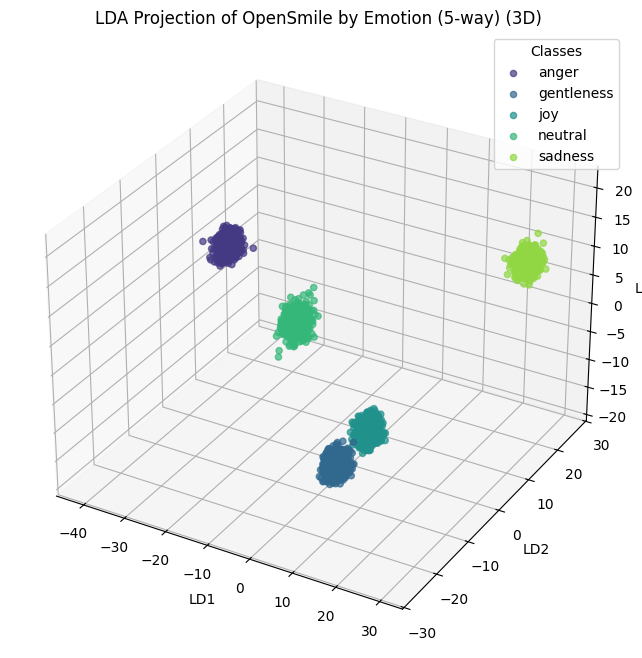

In [ ]:
from scripts.feature_visualisation import prepare_and_plot_lda

prepare_and_plot_lda(
    df_opensmile,
    class_col="emotion",
    mode="3d",
    data_type="OpenSmile (0.5sec) by Emotion (5-way)",
    filters={
        "emotion": [
            "sadness",
            "gentleness",
            "anger",
            "joy",
            "neutral",
        ]
    },
)

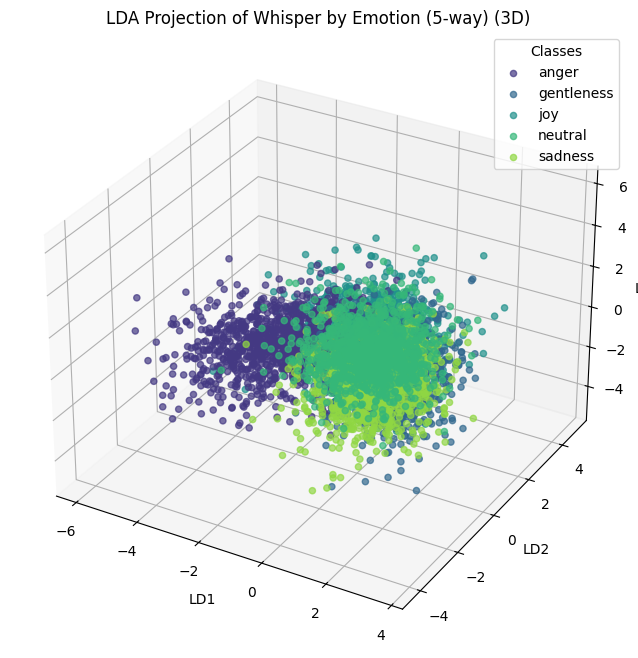

In [ ]:
df_whisper = load_parquet(
    os.path.join(output_dir, "tuni_emotion_dataset_whisper_whisper-base_0.5s.parquet")
)

prepare_and_plot_lda(
    df_whisper,
    class_col="emotion",
    mode="3d",
    data_type="Whisper (0.5sec) by Emotion (5-way)",
        filters={
        "emotion": [
            "sadness",
            "gentleness",
            "anger",
            "joy",
            "neutral",
        ]
    },
)


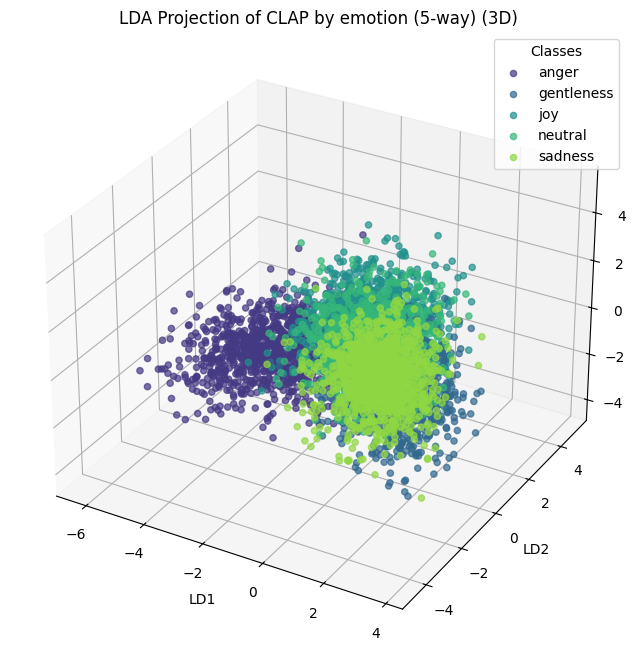

In [ ]:
prepare_and_plot_lda(
    df_clap,
    class_col="emotion",
    mode="3d",
    data_type="CLAP (0.5sec) by emotion (5-way)",
    filters={
        "emotion": [
            "sadness",
            "gentleness",
            "anger",
            "joy",
            "neutral",
        ]
    },
)

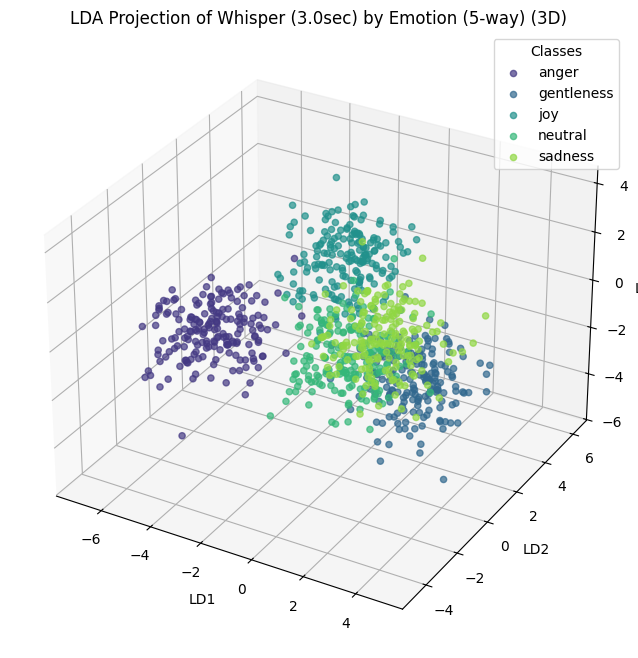

In [50]:
prepare_and_plot_lda(
    load_parquet(
        os.path.join(output_dir, "tuni_emotion_dataset_whisper_whisper-base_3.0s.parquet")
    ),
    class_col="emotion",
    mode="3d",
    data_type="Whisper (3.0sec) by Emotion (5-way)",
)


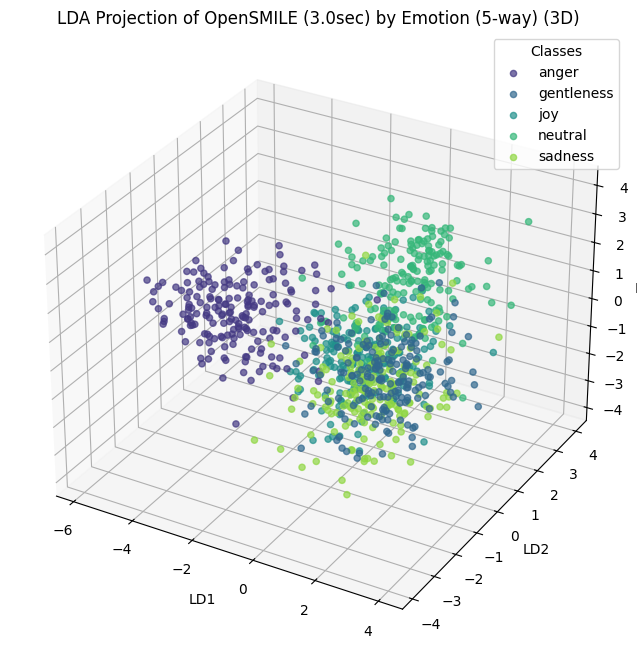

In [51]:
prepare_and_plot_lda(
    load_parquet(
        os.path.join(output_dir, "tuni_emotion_dataset_opensmile-compare-2016_3.0s.parquet")
    ),
    class_col="emotion",
    mode="3d",
    data_type="OpenSMILE (3.0sec) by Emotion (5-way)",
)

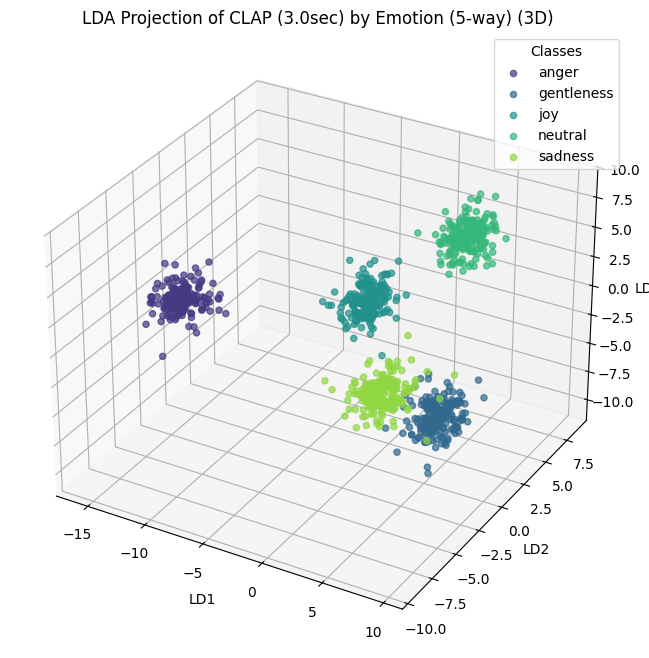

In [52]:
prepare_and_plot_lda(
    load_parquet(
        os.path.join(output_dir, "tuni_emotion_dataset_clap-2023_3.0s.parquet")
    ),
    class_col="emotion",
    mode="3d",
    data_type="CLAP (3.0sec) by Emotion (5-way)",
)